In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [38]:
df = pd.read_csv("cleaned_data/sodic.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [39]:
df.shape

(2753, 6)

In [40]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2753 entries, 2015-01-04 to 2026-04-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       2753 non-null   float64
 1   open        2753 non-null   float64
 2   high        2753 non-null   float64
 3   low         2753 non-null   float64
 4   vol         810 non-null    float64
 5   change_pct  2753 non-null   float64
dtypes: float64(6)
memory usage: 150.6 KB


In [41]:
df.head()

,price,open,high,low,vol,change_pct
date,,,,,,
2015-01-04,14.41,14.49,14.54,14.23,NaN,0.07
2015-01-05,14.38,14.30,14.53,14.26,NaN,-0.21
2015-01-06,13.92,14.03,14.10,13.80,NaN,-3.20
2015-01-08,14.12,14.10,14.25,13.97,NaN,1.44
2015-01-11,13.97,14.01,14.18,13.85,NaN,-1.06


In [42]:
df.tail()

,price,open,high,low,vol,change_pct
date,,,,,,
2026-04-26,21.81,22.38,22.43,21.70,2.02,-1.31
2026-04-27,21.76,22.14,22.20,21.63,1.42,-0.23
2026-04-28,21.92,21.72,22.49,21.72,2.67,0.74
2026-04-29,21.90,21.93,22.21,21.80,1.15,-0.09
2026-04-30,21.71,22.00,22.30,21.56,2.02,-0.87


In [43]:
#print null count
print(df.isnull().sum())

price            0
open             0
high             0
low              0
vol           1943
change_pct       0
dtype: int64


In [44]:
#drop vol column
df.drop(columns="vol", inplace=True)

In [45]:
# 1. Define the anomaly dates
split_date = '2025-08-14'
prev_date = '2025-08-13'

# 2. Extract the prices to calculate the ratio
price_before = df.loc[prev_date, 'price'] # ~61.00
price_after = df.loc[split_date, 'price'] # ~16.26

# 3. Calculate the Adjustment Factor
adj_factor = price_after / price_before 

# 4. Create a mask for all dates strictly BEFORE the split
mask = df.index < pd.to_datetime(split_date)

# 5. Adjust historical prices DOWNWARDS so the transition is smooth
df.loc[mask, 'price'] = df.loc[mask, 'price'] * adj_factor

print(f"Fixed price anomaly on {split_date}. Adjustment factor: {adj_factor:.4f}")

Fixed price anomaly on 2025-08-14. Adjustment factor: 0.2666


In [46]:
#Computing daily % return 
df['return'] = df['price'].pct_change() 

In [47]:
#Adding lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

In [48]:
#Adding rolling features
df['ma_20']         = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5']          = df['price'].rolling(5).mean()

In [49]:
df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

In [50]:
# 1. Calculate the Fast (12-day) and Slow (26-day) Exponential Moving Averages (EMA)
ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()

# 2. Calculate the raw MACD line
df['macd'] = ema_12 - ema_26

# 3. Calculate the Signal Line (9-day EMA of the MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 4. Calculate the MACD Histogram (The most useful feature for ML)
# This represents the distance between the MACD and its signal line
df['macd_hist'] = df['macd'] - df['macd_signal']

# What this does: A rising macd_hist means short-term momentum is accelerating upward.

In [51]:
# 1. Calculate the 20-day SMA (Middle Band) and 20-day Standard Deviation
window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()

# 2. Calculate Upper and Lower Bands
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)

# 3. Feature A: Bollinger %B (Where is price relative to the bands?)
# Value of 1.0 = price is touching upper band. Value of 0.0 = touching lower band.
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)

# 4. Feature B: Bollinger Bandwidth (How volatile is the market right now?)
# Useful for detecting "squeezes" before explosive moves.
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

In [52]:
#Adding RSI
delta = df['price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

In [53]:
threshold = 0.005

future_return = df['return'].shift(-1)

df['label'] = (future_return > threshold).astype(int)

In [54]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [55]:
df.drop(columns=['price', 'ma_5', 'ma_20'], inplace=True)

In [56]:
# Note for modeling team: price, ma_5, ma_20 are in EGP price scale
# while return, rsi etc. are percentages. Please apply StandardScaler or MinMaxScaler before training.
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2733 entries, 2015-02-03 to 2026-04-30
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   open           2733 non-null   float64
 1   high           2733 non-null   float64
 2   low            2733 non-null   float64
 3   change_pct     2733 non-null   float64
 4   return         2733 non-null   float64
 5   return_lag1    2733 non-null   float64
 6   return_lag2    2733 non-null   float64
 7   volatility_20  2733 non-null   float64
 8   dist_to_ma5    2733 non-null   float64
 9   dist_to_ma20   2733 non-null   float64
 10  macd           2733 non-null   float64
 11  macd_signal    2733 non-null   float64
 12  macd_hist      2733 non-null   float64
 13  bb_pb          2733 non-null   float64
 14  bb_bandwidth   2733 non-null   float64
 15  rsi            2733 non-null   float64
 16  label          2733 non-null   int64  
dtypes: float64(16), int64(1)
memory usage: 384.3 

In [57]:
df.head()

,open,high,low,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,
2015-02-03,15.24,15.60,15.24,1.65,0.016469,-0.005242,-0.008447,0.015160,0.004034,0.030006,0.069912,0.067944,0.001968,0.691541,0.156654,68.421053,1
2015-02-04,15.42,15.76,15.36,1.10,0.011017,0.016469,-0.005242,0.015187,0.014832,0.037131,0.071793,0.068714,0.003080,0.738926,0.155407,70.124481,0
2015-02-05,15.40,15.42,15.20,-2.12,-0.021154,0.011017,0.016469,0.013974,-0.005082,0.010656,0.065432,0.068057,-0.002625,0.576997,0.138393,59.459459,0
2015-02-08,15.27,15.43,15.05,-0.33,-0.003274,-0.021154,0.011017,0.013890,-0.007823,0.003693,0.058640,0.066174,-0.007534,0.529899,0.123513,53.974895,0
2015-02-09,15.04,15.20,14.95,-1.18,-0.011827,-0.003274,-0.021154,0.013958,-0.017764,-0.011664,0.048822,0.062703,-0.013881,0.382245,0.099055,45.531915,0


In [58]:
df.tail()

,open,high,low,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,
2026-04-26,22.38,22.43,21.70,-1.31,-0.013122,-0.008969,-0.021930,0.025297,-0.009267,0.063487,0.826045,0.660895,0.165150,0.810439,0.204509,68.411867,0
2026-04-27,22.14,22.20,21.63,-0.23,-0.002293,-0.013122,-0.008969,0.024647,-0.017785,0.054723,0.807235,0.690163,0.117072,0.770451,0.202341,66.546763,1
2026-04-28,21.72,22.49,21.72,0.74,0.007353,-0.002293,-0.013122,0.024530,-0.002639,0.056589,0.796062,0.711343,0.084719,0.778717,0.203034,67.600701,0
2026-04-29,21.93,22.21,21.80,-0.09,-0.000912,0.007353,-0.002293,0.024576,0.000091,0.050108,0.776641,0.724402,0.052238,0.747848,0.202172,66.184448,0
2026-04-30,22.00,22.30,21.56,-0.87,-0.008676,-0.000912,0.007353,0.024750,-0.005041,0.036549,0.737417,0.727005,0.010412,0.682877,0.199856,69.980880,0


In [59]:
#return is the same as change_pct so we can drop change_pct
print((df['return'].round(2) == df['change_pct'].round(2)).value_counts())

False    2525
True      208
Name: count, dtype: int64


In [60]:
df.drop(columns=['open', 'high', 'low', 'change_pct'], inplace=True)

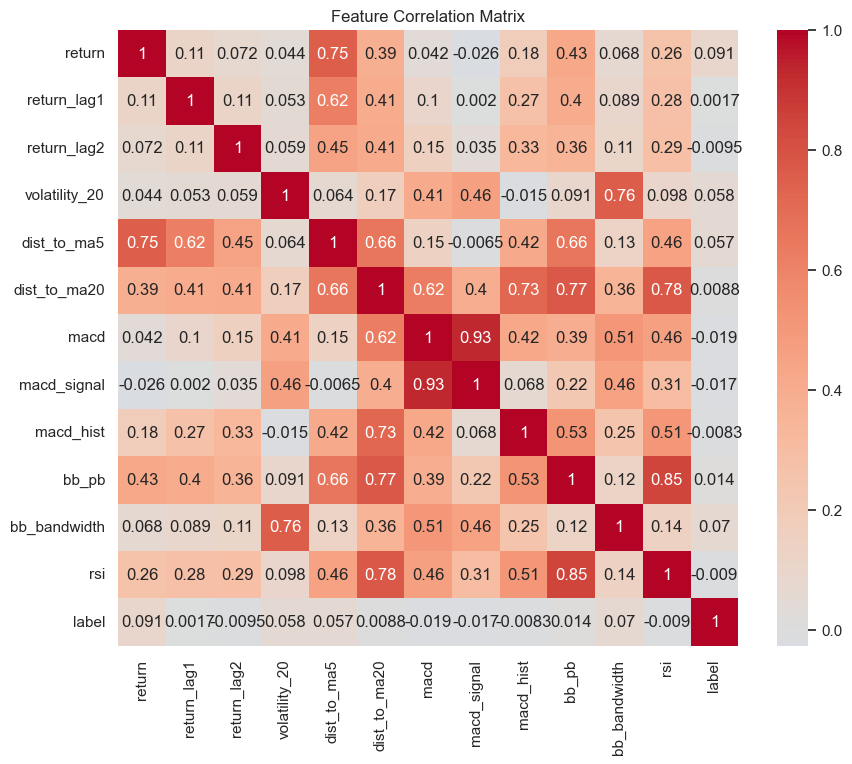

In [61]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [62]:
#Dropping multicolinearity features
df.drop(columns=['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20'], inplace=True)

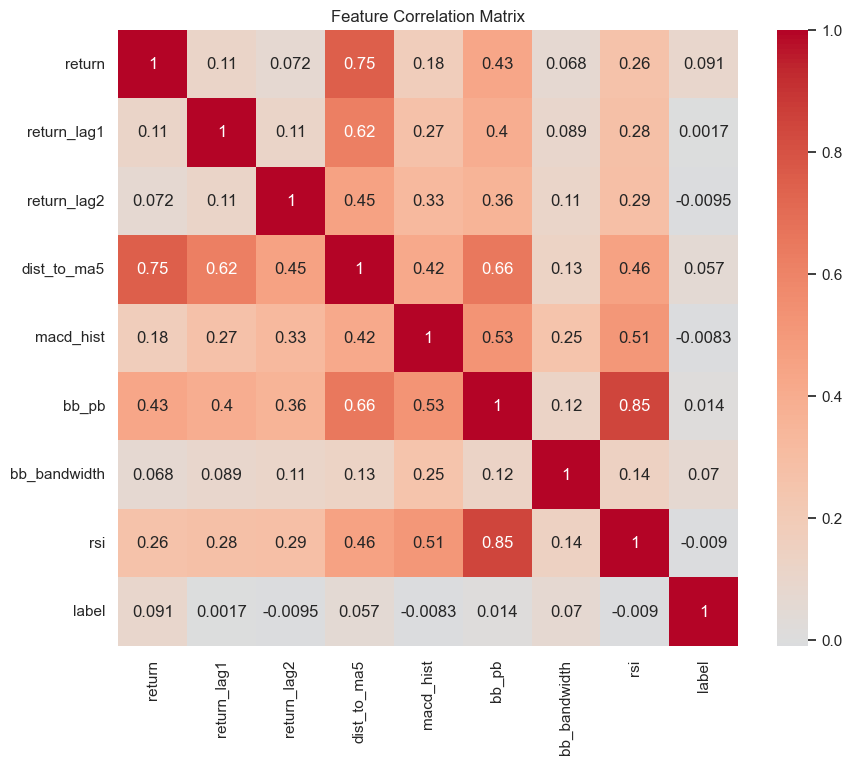

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [65]:
asset_name = "Sodic Index" 
sns.set_theme(style="darkgrid", palette="muted")

# We calculate Cumulative Return to visualize the "price" growth
cum_return = (1 + df['return']).cumprod()

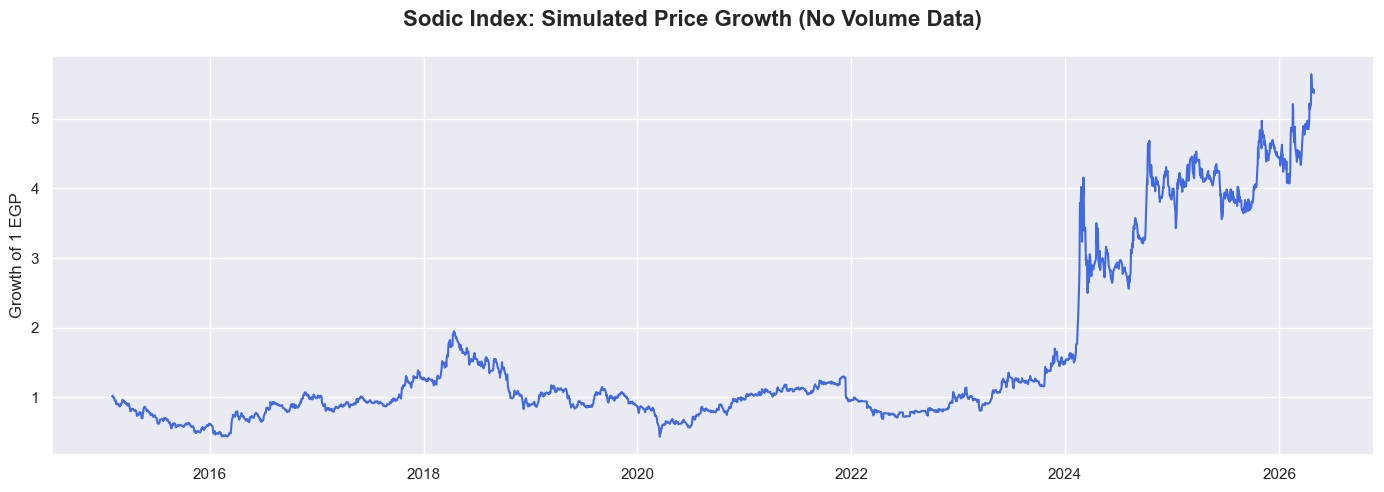

In [66]:
# ========================================================
# PLOT 1 - Macro Trend & Volume
# ========================================================
if 'vol' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f"{asset_name}: Simulated Price Growth & Volume", fontsize=16, fontweight='bold')
    
    # Top Panel: Simulated Price (Cumulative Return)
    axes[0].plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    axes[0].set_ylabel("Growth of 1 EGP")
    axes[0].set_title("Cumulative Returns Over Time")
    
    # Bottom Panel: Volume (FIXED: using fill_between instead of bar)
    axes[1].fill_between(df.index, df['vol'], color='slategray', alpha=0.7)
    axes[1].set_ylabel("Volume")
    axes[1].set_xlabel("Date")
    axes[1].margins(x=0) # Removes white space on the edges
    
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"{asset_name}: Simulated Price Growth (No Volume Data)", fontsize=16, fontweight='bold')
    ax.plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    ax.set_ylabel("Growth of 1 EGP")

plt.tight_layout()
plt.show()

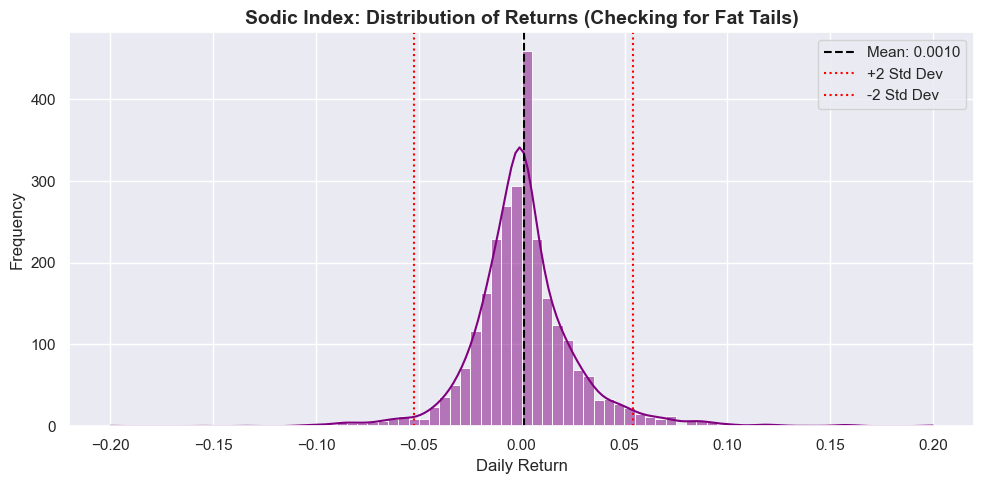

In [67]:
# ========================================================
# PLOT 2 - Distribution of Returns (Fat Tails)
# ========================================================
plt.figure(figsize=(10, 5))
sns.histplot(df['return'], kde=True, bins=80, color='purple')
plt.title(f"{asset_name}: Distribution of Returns (Checking for Fat Tails)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

# Add statistical lines
mean_ret = df['return'].mean()
std_ret = df['return'].std()
plt.axvline(mean_ret, color='black', linestyle='--', label=f'Mean: {mean_ret:.4f}')
plt.axvline(mean_ret + (2*std_ret), color='red', linestyle=':', label='+2 Std Dev')
plt.axvline(mean_ret - (2*std_ret), color='red', linestyle=':', label='-2 Std Dev')

plt.legend()
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_25304\3776502680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


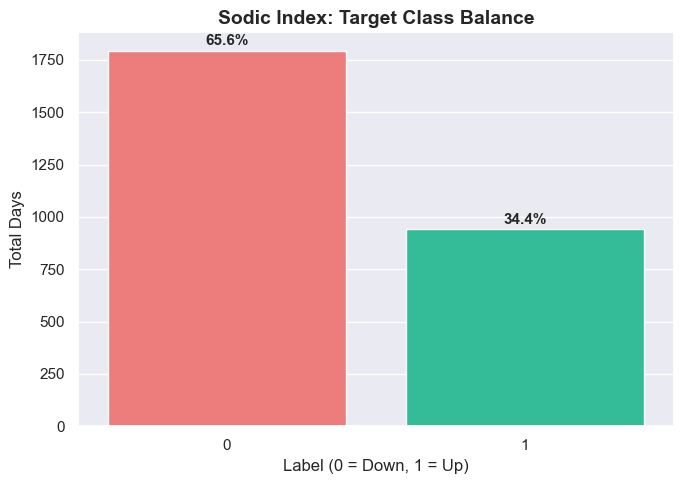

In [68]:
# ========================================================
# PLOT 3 - Target Class Balance
# ========================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])
plt.title(f"{asset_name}: Target Class Balance", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)")
plt.ylabel("Total Days")

# Calculate and add percentages to the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=11)
    
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_25304\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_25304\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_25304\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], pal

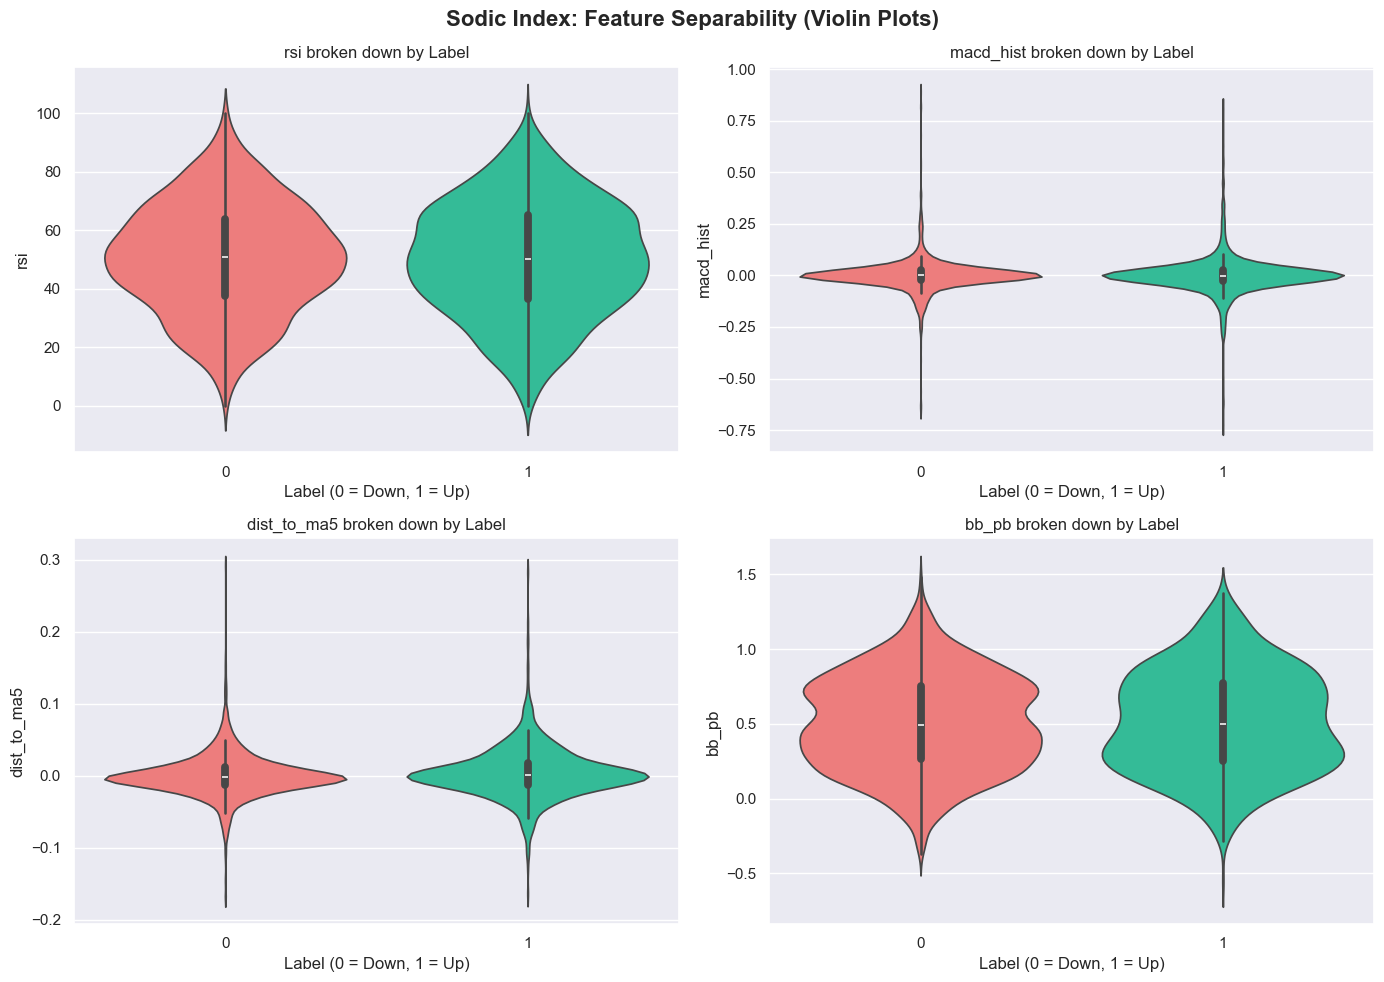

In [69]:
# ========================================================
# PLOT 4 - Feature Predictability (Violin Plots)
# ========================================================
# Selecting the 4 best ML features to plot
features = ['rsi', 'macd_hist', 'dist_to_ma5', 'bb_pb']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"{asset_name}: Feature Separability (Violin Plots)", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

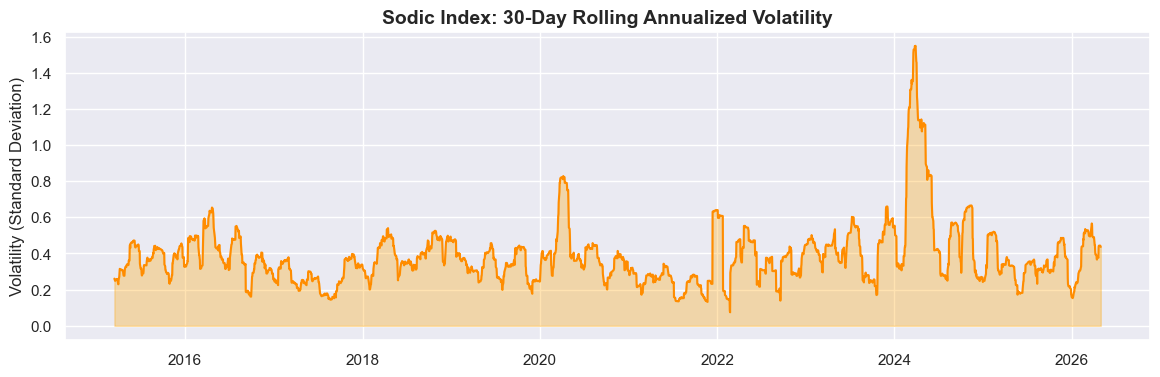

In [70]:
# CELL 7: Rolling Volatility (30-day)
df['rolling_volatility'] = df['return'].rolling(window=30).std() * np.sqrt(252) # Annualized

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['rolling_volatility'], color='darkorange', linewidth=1.5)
plt.title(f"{asset_name}: 30-Day Rolling Annualized Volatility", fontsize=14, fontweight='bold')
plt.ylabel("Volatility (Standard Deviation)")
plt.fill_between(df.index, df['rolling_volatility'], alpha=0.3, color='orange')
plt.show()

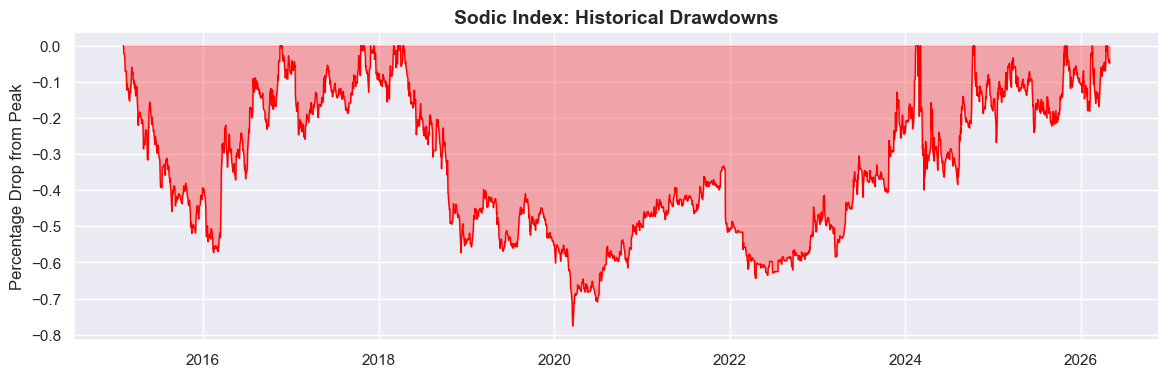

In [71]:
# CELL 8: Drawdown Chart
running_max = cum_return.cummax()
drawdown = (cum_return - running_max) / running_max

plt.figure(figsize=(14, 4))
plt.plot(df.index, drawdown, color='red', linewidth=1)
plt.fill_between(df.index, drawdown, 0, color='red', alpha=0.3)
plt.title(f"{asset_name}: Historical Drawdowns", fontsize=14, fontweight='bold')
plt.ylabel("Percentage Drop from Peak")
plt.show()

In [72]:
df.to_csv('final_data/final_sodic.csv')